In [1]:
import pandas as pd

In [2]:
%pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Predicting College Student Academic Success

## Research Question

How accurately can a student's academic, demographic, and socioeconomic characteristics predict whether they will graduate, drop out, or remain enrolled in college?

In [3]:
from ucimlrepo import fetch_ucirepo

student_data = fetch_ucirepo(id=697)

X = student_data.data.features
y = student_data.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
df.shape

(4424, 37)

In [5]:
df.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [6]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

## 1. Problem Definition

This project asks how accurately a student’s academic, demographic, and socioeconomic characteristics can predict whether the student will **Graduate, Dropout, or remain Enrolled**. Because the target has three possible categories, this is a **multiclass classification** problem.

A model like this could help colleges identify students who may need additional academic or financial support. The goal should be to support students, not to automatically punish or exclude them based on a prediction.


## 2. Background and Context

Student dropout matters because leaving college without completing a degree can affect students, families, institutions, and society. Machine learning can help colleges recognize patterns associated with academic outcomes and potentially identify students who may benefit from early support. The creators of this dataset specifically developed it for predicting dropout and academic success using demographic, socioeconomic, macroeconomic, enrollment, and academic-performance information.

Prior research also shows that machine-learning approaches can be useful for student-success and early-warning systems. However, predictions should be interpreted carefully because student outcomes are influenced by many factors that a dataset cannot fully capture.

### Sources

Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting student dropout and academic success. *Data, 7*(11), 146. https://doi.org/10.3390/data7110146

Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students’ Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

Aulck, L., Nambi, D., Velagapudi, N., Blumenstock, J., & West, J. (2019). Mining university registrar records to predict first-year undergraduate attrition. *Proceedings of the 12th International Conference on Educational Data Mining*.


## 3. Data Description

The data comes from the UCI Machine Learning Repository dataset **Predict Students’ Dropout and Academic Success**. Each row represents one student. The dataset contains **4,424 students**, **36 input features**, and one target variable. The target is `Target`, with the categories `Graduate`, `Dropout`, and `Enrolled`.

The available predictors include academic history, admission information, demographics, socioeconomic indicators, first- and second-semester academic performance, and macroeconomic variables. The dataset reports no missing values. A limitation is that the data comes from one higher-education institution in Portugal, so results may not generalize to every college or student population.


## 4. Data Understanding and Exploration


In [9]:
import matplotlib.pyplot as plt

print(df.describe().T)

print("\nTarget counts:")
print(df["Target"].value_counts())

print("\nTarget percentages:")
print((df["Target"].value_counts(normalize=True) * 100).round(2))


                                                 count         mean  \
Marital Status                                  4424.0     1.178571   
Application mode                                4424.0    18.669078   
Application order                               4424.0     1.727848   
Course                                          4424.0  8856.642631   
Daytime/evening attendance                      4424.0     0.890823   
Previous qualification                          4424.0     4.577758   
Previous qualification (grade)                  4424.0   132.613314   
Nacionality                                     4424.0     1.873192   
Mother's qualification                          4424.0    19.561935   
Father's qualification                          4424.0    22.275316   
Mother's occupation                             4424.0    10.960895   
Father's occupation                             4424.0    11.032324   
Admission grade                                 4424.0   126.978119   
Displa

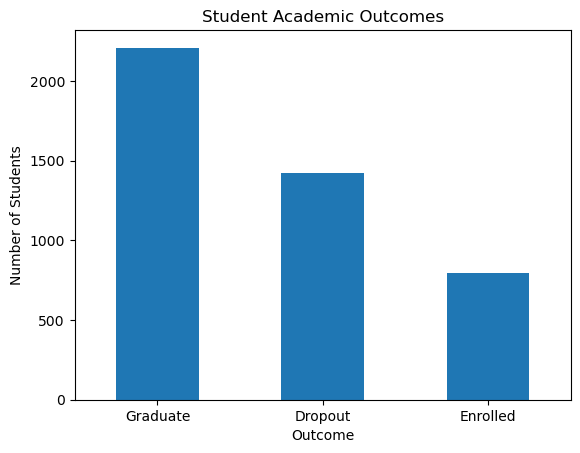

In [10]:
df["Target"].value_counts().plot(kind="bar")
plt.title("Student Academic Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()


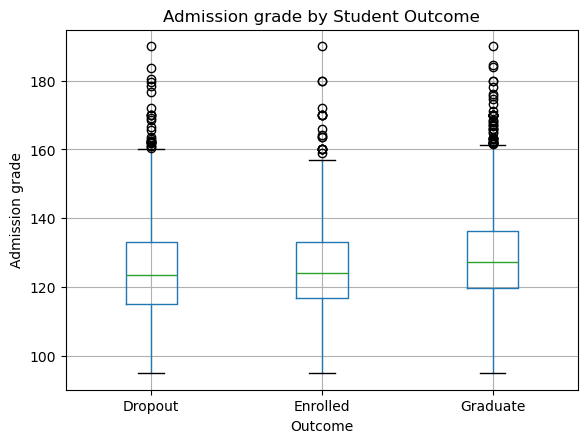

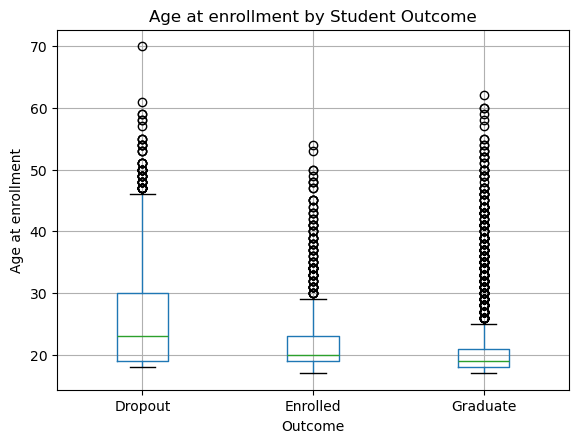

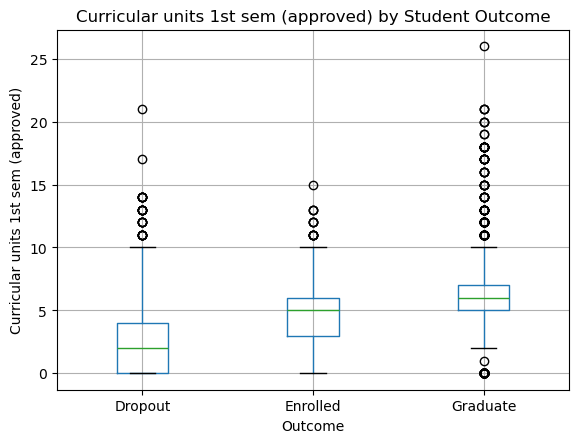

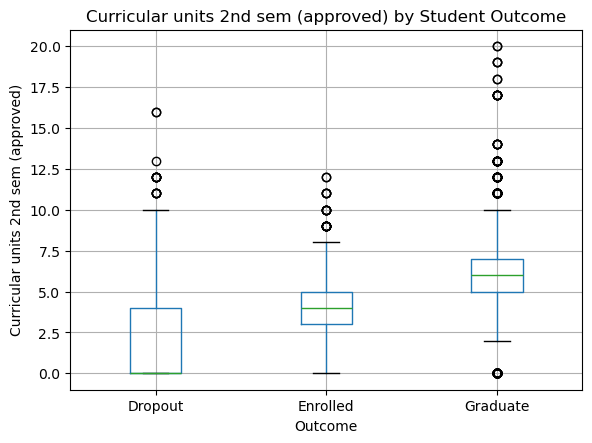

In [11]:
features_to_plot = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]

for feature in features_to_plot:
    df.boxplot(column=feature, by="Target")
    plt.title(f"{feature} by Student Outcome")
    plt.suptitle("")
    plt.xlabel("Outcome")
    plt.ylabel(feature)
    plt.show()


The target distribution shows that the classes are not perfectly balanced, with graduates being the largest group and currently enrolled students being the smallest. Because of this imbalance, accuracy alone is not enough to evaluate the models. I also use macro-averaged precision, recall, and F1 score so that performance on all three classes matters.

The academic variables are especially important to explore because semester performance is directly connected to student progress. Admission grade and age provide additional information available earlier in the student pathway.


## 5. Data Preparation and Feature Selection

The dataset contains no missing values, so no imputation is needed. I remove duplicate rows if any are present. I use all 36 provided predictor variables and keep `Target` separate as the outcome. Because many columns are categorical variables stored as integer codes, I one-hot encode selected categorical columns. Numerical variables are standardized for logistic regression.

The train/test split is stratified so the proportions of Graduate, Dropout, and Enrolled students remain similar in both sets. Preprocessing is placed inside a pipeline and learned only from the training data, which helps prevent data leakage.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

df = df.drop_duplicates().copy()
X = df.drop(columns="Target")
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_cols = [
    "Marital Status", "Application mode", "Course",
    "Daytime/evening attendance", "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", "Displaced",
    "Educational special needs", "Debtor", "Tuition fees up to date",
    "Gender", "Scholarship holder", "International"
]

numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 3539
Testing rows: 885


## 6. Baseline and Model Development

The baseline predicts the most common class every time. A useful trained model should outperform this simple strategy. I compare two classification models: **Logistic Regression** and **Random Forest**. Logistic regression provides a simple, interpretable linear baseline, while random forest can capture more complex nonlinear relationships and interactions.


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

baseline = DummyClassifier(strategy="most_frequent")
logistic = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])
random_forest = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1
    ))
])

baseline.fit(X_train, y_train)
logistic.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

print("Models trained successfully.")


Models trained successfully.


## 7. Model Evaluation and Selection

I evaluate each model with accuracy and macro F1. Accuracy measures the overall percentage of correct predictions. Macro F1 gives equal importance to each outcome class, which is useful because the classes are imbalanced. I also inspect precision, recall, and confusion matrices.


In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import pandas as pd

models = {
    "Baseline": baseline,
    "Logistic Regression": logistic,
    "Random Forest": random_forest
}

results = []
predictions = {}

for name, model in models.items():
    pred = model.predict(X_test)
    predictions[name] = pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Macro F1": f1_score(y_test, pred, average="macro")
    })

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
print(results_df.round(3).to_string(index=False))

best_name = results_df.iloc[0]["Model"]
print("\nBest model by Macro F1:", best_name)
print("\nClassification report:")
print(classification_report(y_test, predictions[best_name]))


              Model  Accuracy  Macro F1
Logistic Regression     0.725     0.689
      Random Forest     0.765     0.678
           Baseline     0.499     0.222

Best model by Macro F1: Logistic Regression

Classification report:
              precision    recall  f1-score   support

     Dropout       0.82      0.68      0.74       284
    Enrolled       0.42      0.64      0.50       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



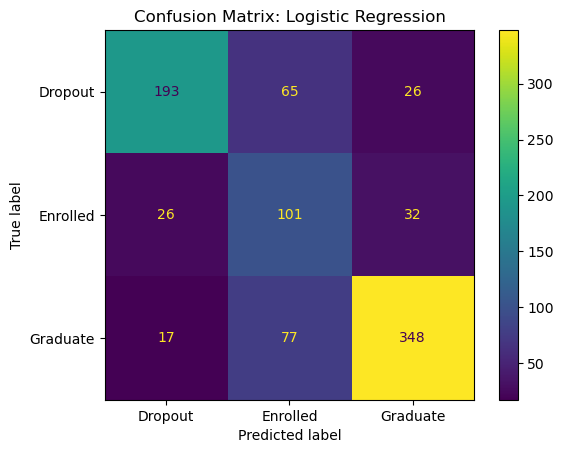

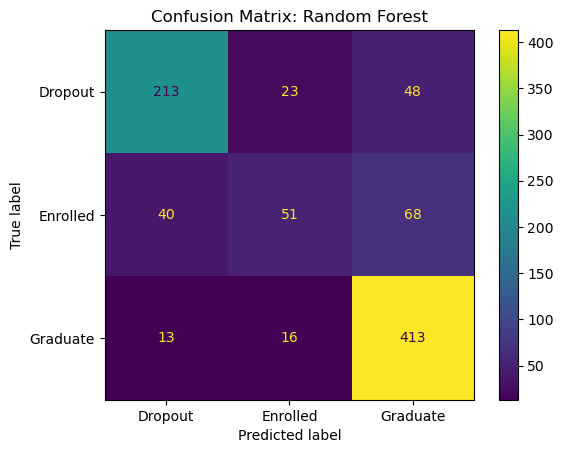

In [15]:
for name in ["Logistic Regression", "Random Forest"]:
    ConfusionMatrixDisplay.from_predictions(y_test, predictions[name])
    plt.title(f"Confusion Matrix: {name}")
    plt.show()


The final model is selected using **macro F1** rather than accuracy alone. This is important because a model could obtain a good accuracy score by doing well on the largest class while performing poorly on a smaller class. The table and classification report above provide the evidence for which trained model performs best.


## 8. Model Interpretation and Insights


                                    Feature  Importance
   num__Curricular units 2nd sem (approved)    0.090437
      num__Curricular units 2nd sem (grade)    0.077166
   num__Curricular units 1st sem (approved)    0.061421
      num__Curricular units 1st sem (grade)    0.056504
num__Curricular units 2nd sem (evaluations)    0.040290
num__Curricular units 1st sem (evaluations)    0.036966
                       num__Admission grade    0.036768
                     num__Age at enrollment    0.032723
        num__Previous qualification (grade)    0.032483
             cat__Tuition fees up to date_1    0.023132
                                   num__GDP    0.023036
                     num__Unemployment rate    0.022240
                        num__Inflation rate    0.020556
   num__Curricular units 2nd sem (enrolled)    0.020018
             cat__Tuition fees up to date_0    0.019433


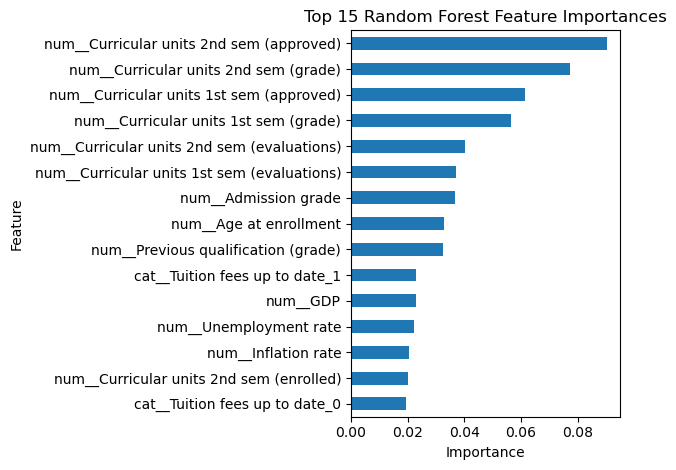

In [16]:
# Random Forest feature importance
rf_prep = random_forest.named_steps["prep"]
rf_model = random_forest.named_steps["model"]
feature_names = rf_prep.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

print(importance_df.to_string(index=False))

importance_df.sort_values("Importance").plot(
    kind="barh", x="Feature", y="Importance", legend=False
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


The feature-importance chart shows which variables the random forest relied on most when making predictions. High importance means that a feature was useful for splitting students into outcome groups, but it does **not** prove that the feature causes graduation or dropout.

The confusion matrices show where each model performs well and which outcomes it confuses. This is especially important for dropout prediction because incorrectly labeling an at-risk student could affect how support resources are offered.


## 9. Limitations, Ethics, and Reflection

This model has several limitations. First, the dataset comes from a single higher-education institution in Portugal, so its patterns may not represent students at other universities or in other countries. Second, demographic and socioeconomic variables can reflect existing inequalities. A model trained on historical data can reproduce those patterns. Third, even a strong model will make mistakes.

False negatives are important because a student who is actually at risk of dropping out might not receive support. False positives also matter because a student could be incorrectly labeled as at risk. For that reason, this model should not be used to automatically deny admission, scholarships, courses, or other opportunities. A safer use would be as one source of information for offering optional support, with human review and additional context.

The model also cannot establish causation. Feature importance only describes predictive usefulness in this dataset. Future work could test the model on students from different institutions, examine fairness across demographic groups, tune hyperparameters, and compare additional algorithms.


## 10. Code and Transparency

The complete analysis and code are contained in this Jupyter Notebook. The dataset was obtained from the UCI Machine Learning Repository and is cited above.

### AI Usage Disclosure

I used **ChatGPT (OpenAI)** to help organize the notebook, write and debug Python code, explain machine-learning steps, and draft portions of the written interpretation. I reviewed the notebook structure and code as part of completing the project.

### Reproducibility

The notebook uses a fixed `random_state=42` for the train/test split and machine-learning models where applicable so results can be reproduced. The UCI dataset is loaded directly using `ucimlrepo`.
